In [7]:
import numpy as np
import pandas as pd
import pyvista as pv
import gdist
from scipy.spatial.distance import cdist
from pathlib import Path
import subprocess
import pymeshfix
import matplotlib.pyplot as plt
from tqdm import tqdm

from phd_helpers.CartilageGeneration import (
    mesh_checks, bone_cartilage_checks, get_outward_normal_mask, flip_faces, taper_f, get_nearest_boundary, 
    interp_vecs, get_triangle_adjacency, flood_fill_cells, remove_normals, get_min_df_fast, check_points_still_there,
    fill_holes_pmf
)
from phd_helpers.paths import (
    find_corresponding_cells, identical_points_count, get_subject_stl_path, get_boundary, get_project_root
)

from phd_helpers.MeshQuality import (
        compute_d_metrics, compute_dists, compute_mesh_metrics, compute_rmsd, sample_surface
    )

In [8]:
# INPUTS #
mesh_id = '-1'

# meshes have 2.5mm of 0.2mm fine mesh for 50 taubin input
output_root = Path('../../BonePrep/RemeshJustification/outputs-redo/iterations/meshes')
subs_ok = [p.name for p in output_root.iterdir() if p.is_dir()]

# main params
remesh_cartilage = True
cartilage_remesh_name = f'CartilageCap.obj' # cartilage cap mesh file name
# path to c++ fixed boundary input
cgal_input_path = Path(f'../../../../MeshPipeline/cpp/2Dmesh/inputs/fb_input/{cartilage_remesh_name}')

taper_width = 1.5 # width of cartilage taper region (limit - only tapers if above taper curve)
#max_height = 1 # max height of cartilage in taper region
p_h = 8.5 # shape of taper height (1 = linear , higher = steeper taper)
p_v = 1 # shape of vector ratio (1 = linear)
cartilage_smooth_iters = 100 # need to look at this, currently uses laplacian 
edge_length = 0.2 # target edge length of cartilage remesh
n_iters = 5 # n isotropic remeshing iterations for cartilage remesh

In [58]:
n_samples = 20000
iters = [25, 50, 100, 200, 400, 800, 1600]

smooth_data = []
for sub in tqdm(subs_ok):
    subject, sideL = sub[:-1], sub[-1]
    for bone, ar_bone in [['tpm', 'mc1'], ['mc1', 'tpm']]:   


        output_dir = output_root / f"{subject}{sideL}/{bone}-{ar_bone}"
        output_path = output_dir / '2Dmesh'
        compute_quality = False

        bone_mesh = pv.read(output_path / f'bone_remesh{mesh_id}.obj')
        ar_path = output_dir.parent / f"{ar_bone}-{bone}/2Dmesh/bone_remesh{mesh_id}.obj"
        arbone_mesh = pv.read(ar_path)

        # compute min df
        stl_path = get_subject_stl_path(subject, sideL)
        max_gap_cartilage = 2
        poses = ['adduction','abduction','flexion','extension','pinch','grasp','jar','neutral']
        min_df = get_min_df_fast(stl_path, bone, ar_bone, bone_mesh, arbone_mesh, poses, max_gap_cartilage)





        # main
        ################# MESH STUFF #################
        bone_mesh['Normals'] = bone_mesh.compute_normals(point_normals=True, cell_normals=False)['Normals']
        bone_mesh['bone_id'] = np.arange(bone_mesh.n_points)
        bone_mesh['bone_cell_id'] = np.arange(bone_mesh.n_cells)
        ################# MESH STUFF #################


        ################# COMPUTE TAPER REGION #################
        # extract mesh of cartilage points on bone mesh (makes gdist computation faster) - (bone-cartilage interface mesh)
        inter_mesh = bone_mesh.extract_points(min_df['bone_id'], adjacent_cells=False).extract_surface(algorithm=None)
        inter_mesh['inter_cell_ids'] = np.arange(inter_mesh.n_cells)
        # remove any missing points due to extract geometry (so remove any points not part of a complete triangle)
        missing_mask = ~np.isin(min_df['bone_id'], inter_mesh['bone_id'])
        min_df.drop(min_df['bone_id'][missing_mask].index.values, inplace=True)

        # useful values from min_df (min_df does not change after this point - final change was at min_df.drop(missing))
        midpoint_dist = min_df['dist'] / 2 # distance of midpoint between two bones for each pair of closest points
        midpoints = np.array(min_df['midpoint'].tolist()) # midpoint coordinates
        #ar_points = np.array(min_df['ar_point'].tolist()) # closest points on ar bone to each bone point


        # get boundary of cartilage on inter mesh
        inter_boundary = get_boundary(inter_mesh)
        boundary_mask_inter = np.isin(inter_mesh['bone_id'], inter_boundary['bone_id']) 
        boundary_ids = np.arange(inter_mesh.n_points)[boundary_mask_inter] # on inter_mesh

        # minimum geo dist of every node from closest source_idx
        geo_dists = gdist.compute_gdist(
            inter_mesh.points.astype(np.float64),
            inter_mesh.faces.reshape(-1, 4)[:, 1:].astype(np.int32),
            source_indices=boundary_ids.astype(np.int32), 
        ) 

        # get mask of nodes within taper width and below taper function
        #taper_heights = taper_f(geo_dists, taper_width, max_height, p=p_h)
        #taper_mask = (taper_heights <= min_df['dist'] / 2) & (geo_dists<=taper_width)
        taper_mask = geo_dists<=taper_width




        # get taper points mesh (makes computation much faster) - mesh of only taper region
        taper_mask_inter = np.isin(inter_mesh['bone_id'], min_df['bone_id'][taper_mask])
        taper_mesh = inter_mesh.extract_points(taper_mask_inter, adjacent_cells=False).extract_surface(algorithm=None)
            # assign non-taper cells that lie on "pinched" islands to taper region
        not_taper_mesh = inter_mesh.extract_cells(taper_mesh['inter_cell_ids'], invert=True).extract_surface(algorithm=None)
        edge_map, adjacency = get_triangle_adjacency(not_taper_mesh)
        start_face = not_taper_mesh.find_closest_cell(np.mean(not_taper_mesh.points, axis=0)) # not best way of doing this!
        inner_cells = flood_fill_cells(not_taper_mesh, start_face, get_boundary(not_taper_mesh).lines.reshape(-1, 3)[:, 1:], adjacency)
            # final taper mesh #
        taper_mesh = inter_mesh.extract_cells(not_taper_mesh['inter_cell_ids'][inner_cells], invert=True).extract_surface(algorithm=None)
            # remove any missing points from taper_mask after extracting geometry and islands - not ideal but quicker than using inter mesh
        taper_mask = np.isin(min_df['bone_id'], taper_mesh['bone_id'])
        #taper_geo_dists = geo_dists[taper_mask]

        # geo_dist between all points within max_distance
        geo_dists_matrix = gdist.local_gdist_matrix(
            taper_mesh.points.astype(np.float64),
            taper_mesh.faces.reshape(-1, 4)[:, 1:].astype(np.int32),
            max_distance=taper_width+1e-3
        ) 

        # get taper mesh boundaries
        taper_boundary = get_boundary(taper_mesh)
        boundary_outer_mask_tb = np.isin(taper_boundary['bone_id'], inter_boundary['bone_id']) # on taper_boundary

        # get taper boundary innner and outer nodes on taper mesh
        taper_outer_mask = np.isin(taper_mesh['bone_id'], taper_boundary['bone_id'][boundary_outer_mask_tb]) # on taper_mesh
        taper_inner_mask = np.isin(taper_mesh['bone_id'], taper_boundary['bone_id'][~boundary_outer_mask_tb]) # on taper_mesh
        taper_outer_ids = np.arange(taper_mesh.n_points)[taper_outer_mask] # on taper_mesh
        taper_inner_ids = np.arange(taper_mesh.n_points)[taper_inner_mask] # on taper_mesh

        # ids and distances of boundary nodes that are closest to each taper node
        _, near_taper_outer_D = get_nearest_boundary(taper_outer_ids, geo_dists_matrix) # ids on taper_mesh
        near_taper_inner_ids, near_taper_inner_D = get_nearest_boundary(taper_inner_ids, geo_dists_matrix) # ids on taper_mesh
        # Distance fraction of each taper_mesh point from closest outer_node to closest_inner node
        taper_Df = (near_taper_outer_D) / (near_taper_outer_D + near_taper_inner_D)

        # get nearest inner node midpoint heights
        taper_inner_mask_c = np.isin(min_df['bone_id'], taper_mesh['bone_id'][taper_inner_ids]) # on c_mesh
        inner_node_midpoint_heights = midpoint_dist.values[taper_inner_mask_c]
        near_inner_node_midpoint_heights = inner_node_midpoint_heights[np.searchsorted(taper_inner_ids, near_taper_inner_ids)]

        # set taper node heights
        taper_heights = taper_f(taper_Df, 1, near_inner_node_midpoint_heights, p=p_h) # non-linear

        # set vector directions
        midpoint_vecs = midpoints - bone_mesh.points[min_df['bone_id']] # vector from bone point to midpoint
        taper_vecs_mid = midpoint_vecs[taper_mask] # midpoint_vecs
        taper_vecs_norm = bone_mesh['Normals'][min_df['bone_id']][taper_mask] # normal vecs
        vec_dirs = taper_f(taper_Df, 1, 1, p=p_v)
        taper_vecs = interp_vecs(taper_vecs_norm, taper_vecs_mid, vec_dirs)

        # get taper coords
        taper_points = bone_mesh.points[min_df['bone_id']][taper_mask]
        taper_points = taper_points + taper_heights.reshape(-1, 1)*taper_vecs

        # get taper points
        points_tapered = midpoints.copy()
        points_tapered[taper_mask] = taper_points

        #closest_points, distances, cell_ids = get_trimesh(bone_mesh).nearest.on_surface(points_tapered)
        ################# COMPUTE TAPER REGION #################

        ################# MESH TAPER REGION #################
        # map faces from bone mesh to extruded taper region points
        # mesh curves down in taper region and delaunay doesn't like that
        tapered_mesh = pv.PolyData(taper_points, taper_mesh.faces)
        ################# MESH TAPER REGION #################




        ################# MESH INNER REGION #################
        tapered_edge = get_boundary(tapered_mesh)

        inner_edge = tapered_edge.extract_points(~boundary_outer_mask_tb).extract_surface(algorithm=None)
        #inner_points = pv.PolyData(midpoints[~taper_mask])
        inner_mesh = pv.PolyData(np.vstack( (inner_edge.points, midpoints[~taper_mask]) ), lines=inner_edge.lines)

        # alpha for coarse meshes wants to be slightly lower and vice versa - I think
        inner_mesh = inner_mesh.delaunay_2d(edge_source=inner_edge, alpha=0.9).triangulate()
        inner_mesh = inner_mesh.fill_holes(inner_mesh.area/20)
        #inner_mesh.lines = inner_edge.lines # reset edge lines to remove delaunay leftover lines
        inner_mesh.lines = np.empty(0, dtype='int64') # remove all lines for now cos they show up in mesh.faces

        # remove cells that lie outside of the inner region boundary
        edge_map, adjacency = get_triangle_adjacency(inner_mesh)
        #start_face = inner_mesh.find_closest_cell(np.mean(inner_mesh.points, axis=0))
        start_face = inner_mesh.find_closest_cell(inner_mesh.center) # new 28/03/26
        inner_cells = flood_fill_cells(inner_mesh, start_face, inner_edge.lines.reshape(-1, 3)[:, 1:], adjacency)
        inner_mesh_clean = pv.PolyData(inner_mesh.points, inner_mesh.faces.reshape(-1, 4)[inner_cells])
        # should maybe be calling remove unused points here, lines bring their own points that are left behind?
        ################# MESH INNER REGION #################




        ################# COMBINE INNER MESH AND TAPER MESH #################
        #edge_check1 = np.isin(inner_edge.points, tapered_mesh.points).all()
        edge_check1 = identical_points_count(inner_edge.points, tapered_mesh.points) == inner_edge.n_points #*** new
        #edge_check2 = np.isin(inner_edge.points, inner_mesh_clean.points).all()
        edge_check2 = identical_points_count(inner_edge.points, inner_mesh_clean.points) == inner_edge.n_points #*** new

        inner_mesh_clean['inner_cells'] = np.full(inner_mesh_clean.n_cells, 1)
        tapered_mesh['inner_cells'] = np.full(tapered_mesh.n_cells, 0)
        mesh = inner_mesh_clean + tapered_mesh # full cartilage cap mesh
            # check if there are any holes at boundary between inner mesh and tapered mesh and try to fill them
        if get_boundary(mesh).connectivity()['RegionId'].any():
            mesh = fill_holes_pmf(mesh, nbe=20)
            mesh['inner_cells'] = np.ones(mesh.n_cells, dtype=int)
            mesh['inner_cells'][find_corresponding_cells(mesh, tapered_mesh, raise_error=True)] = 0
        else:
            if not mesh.n_points == midpoints.shape[0]: # had to move to else cos pymeshfix messes with stuff sometimes
                raise AssertionError('Not all midpoints in mesh (& no dupes)')

        if not edge_check1:
            raise AssertionError('Not all boundary points in tapered mesh')
        if not edge_check2:
            raise AssertionError('Not all boundary points in inner mesh')

        # check for flat faces
        #closest_points, implicit_distances, cell_ids = get_trimesh(bone_mesh).nearest.on_surface(mesh.points)
        _, ps = bone_mesh.find_closest_cell(mesh.points, return_closest_point=True)
        implicit_distances = np.linalg.norm(mesh.points - ps, axis=1) #*** changed from line above

        mesh_faces = mesh.faces.reshape(-1, 4)[:, 1:]
        flat_face_mask = (implicit_distances[mesh_faces] <= 1e-12).all(axis=1) #*** changed from ==0 to <=1e-12
        #flat_face_ids = np.where(flat_face_mask)[0]

        # remove flat faces and leftover points - occur when all 3 vertices lie on the boundary
        mesh_clean = pv.PolyData(mesh.points, mesh.faces.reshape(-1, 4)[~flat_face_mask]).compute_normals(auto_orient_normals=True)
        mesh_clean.remove_unused_points(inplace=True)
        mesh_clean['mesh_clean_id'] = np.arange(mesh_clean.n_points)
        # get array of inner points/cells on mesh_clean 
        mesh_clean['inner_cells'] = mesh['inner_cells'][find_corresponding_cells(mesh, mesh_clean)]
        mesh_clean['inner_points'] = np.full(mesh_clean.n_points, 1)
        mesh_clean['inner_points'][np.unique(mesh_clean.faces.reshape(-1, 4)[:, 1:][np.where(mesh_clean['inner_cells']==0)[0]])] = 0
        #mesh_clean['inner_points'] = np.zeros(mesh_clean.n_points, dtype=int)
        #for p in inner_mesh_clean.points:
        #    mesh_clean['inner_points'][mesh_clean.find_closest_point(p)] = 1

        # get edge points on mesh and bone_mesh
        mesh_clean_edge = get_boundary(mesh_clean)
        mesh_clean_edge_mask = np.isin(mesh_clean['mesh_clean_id'], mesh_clean_edge['mesh_clean_id']) # on mesh_clean
        mesh_edge_ids = mesh_clean['mesh_clean_id'][mesh_clean_edge_mask] # on mesh_clean
        mesh_edge_points = mesh_clean.points[mesh_clean_edge_mask] # on mesh_clean

        #print('Checking mesh boundary has not changed')
        #bone_mesh_edge_ids = check_points_still_there(bone_mesh, mesh_edge_points)
        _, bone_mesh_edge_ids, _ = identical_points_count(bone_mesh.points, mesh_edge_points, return_indices=True) #*** new
        bone_mesh_edge_ids = np.sort(bone_mesh_edge_ids)
        if len(bone_mesh_edge_ids) != len(mesh_edge_points):
            raise AssertionError("Mesh boundary has changed")


        if (mesh.n_cells - mesh_clean.n_cells) != flat_face_mask.sum():
            raise AssertionError("Not all flat faces removed")
        ################# COMBINE INNER MESH AND TAPER MESH #################
        #print('Created cartilage cap')




        for n_iter in iters:
            #print('Smoothing cartilage cap')
            ################# SMOOTH CARTILAGE MESH CAP #################
            cartilage_cap = mesh_clean.smooth(
            n_iter=n_iter,
            feature_angle=180, # prevent anything from being feature cos I don't understant feature_smoothing arg...
            boundary_smoothing = False, # keeps boundary fixed-ish
            feature_smoothing = False # prevents feature edges from being identified - so they get smoothed?... (idk stupid)
            )
            cartilage_cap_edge = get_boundary(cartilage_cap)

            if cartilage_cap_edge.n_points != mesh_clean_edge.n_points:
                raise AssertionError(f'{cartilage_cap_edge.n_points - mesh_clean_edge.n_points} Boundary points lost during smoothing')
            #_ = check_points_still_there(mesh_clean_edge, cartilage_cap_edge.points)

            # put edge points back so they are numerically identical
            cartilage_cap.points[mesh_edge_ids] = bone_mesh.points[bone_mesh_edge_ids]


            # distance of inner points from mesh
            inner_cap = cartilage_cap.extract_points(cartilage_cap['inner_points'].astype(bool), adjacent_cells=False).extract_surface(algorithm=None)
            inner_clean = mesh_clean.extract_points(mesh_clean['inner_points'].astype(bool), adjacent_cells=False).extract_surface(algorithm=None)

            d_ab = compute_dists(sample_surface(inner_cap, n_samples), mesh_clean)
            d_ba = compute_dists(sample_surface(inner_clean, n_samples), cartilage_cap)
            d = np.hstack((d_ab, d_ba))

            clean_sample = sample_surface(inner_clean, n_samples)
            _, cap_sample = inner_cap.find_closest_cell(clean_sample, return_closest_point=True)
            
            h_before = compute_dists(clean_sample, bone_mesh) # before 2 bone
            h_after = compute_dists(cap_sample, bone_mesh) # after 2 bone
            h_diff = h_before - h_after
            h_ratio = h_diff / h_before

            mets = {
                'sub': sub,
                'bone': bone,
                'n_iter': n_iter,
                'rmsd': compute_rmsd(d),
                'h_before_rmsd': compute_rmsd(h_before),
                'h_after_rmsd': compute_rmsd(h_after),
                'h_diff_rmsd': compute_rmsd(h_diff),
                'h_ratio_rmsd': compute_rmsd(h_diff)
            }
            # distance
            mets = compute_d_metrics(d, mets, 'd_')
            mets = compute_d_metrics(h_before, mets, 'h_before_')
            mets = compute_d_metrics(h_after, mets, 'h_after_')
            mets = compute_d_metrics(h_diff, mets, 'h_diff_')
            mets = compute_d_metrics(h_ratio, mets, 'h_ratio_')  
            # surface
            mets = compute_mesh_metrics(inner_clean, mets, vol=False, edge_length=False, label='before_')
            mets = compute_mesh_metrics(inner_cap, mets, vol=False, edge_length=False, label='after_')

            smooth_data.append(mets)
pd.DataFrame(smooth_data).to_csv('taperSmoothingMetrics-redo.csv', index=False)

 31%|███       | 11/36 [02:47<06:37, 15.90s/it]

INFO- Loaded 5925 vertices and 11531 faces.

100% done 
INFO- Loaded 5885 vertices and 11460 faces.

100% done 


100%|██████████| 36/36 [09:33<00:00, 15.94s/it]


In [63]:
pl = pv.Plotter()
pl.add_mesh(cartilage_cap, scalars='inner_cells', cmap='Accent_r')
#pl.add_mesh(mesh_clean, scalars='inner_cells', cmap='Accent_r')
#pl.add_points(cap_sample)
#pl.add_points(clean_sample, color='magenta')
pl.show()

Widget(value='<iframe src="http://localhost:53313/index.html?ui=P_0x3366f7440_9&reconnect=auto" class="pyvista…

In [64]:
df = pd.read_csv('taperSmoothingMetrics-redo.csv')
df

,sub,bone,n_iter,rmsd,h_before_rmsd,h_after_rmsd,h_diff_rmsd,h_ratio_rmsd,d_mean,d_median,...,h_ratio_std,h_ratio_max,h_ratio_99,h_ratio_95,before_points,before_cells,before_A,after_points,after_cells,after_A
0,14818R,tpm,25,0.000734,0.466063,0.465717,0.000726,0.000726,0.000470,0.000299,...,0.001327,0.014109,0.004927,0.002908,2973,5721,76.582988,2973,5721,76.546785
1,14818R,tpm,50,0.001401,0.466914,0.466233,0.001391,0.001391,0.000908,0.000584,...,0.002536,0.022370,0.009553,0.005536,2973,5721,76.582988,2973,5721,76.522803
2,14818R,tpm,100,0.002567,0.467219,0.465901,0.002589,0.002589,0.001695,0.001111,...,0.004682,0.038577,0.016737,0.010525,2973,5721,76.582988,2973,5721,76.495628
3,14818R,tpm,200,0.004598,0.468443,0.465917,0.004648,0.004648,0.003157,0.002175,...,0.008275,0.058429,0.029578,0.018622,2973,5721,76.582988,2973,5721,76.480130
4,14818R,tpm,400,0.008122,0.465696,0.460910,0.008148,0.008148,0.005761,0.004163,...,0.014390,0.078709,0.050034,0.033010,2973,5721,76.582988,2973,5721,76.498988
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
499,15283R,mc1,100,0.002837,0.350509,0.349345,0.002878,0.002878,0.001756,0.001058,...,0.008015,0.085623,0.030665,0.017477,4408,8538,130.185167,4408,8538,129.987272
500,15283R,mc1,200,0.005006,0.351239,0.349102,0.004944,0.004944,0.003215,0.001977,...,0.013987,0.141670,0.051325,0.030932,4408,8538,130.185167,4408,8538,129.953800
501,15283R,mc1,400,0.008554,0.350919,0.346909,0.008553,0.008553,0.005732,0.003650,...,0.024932,0.243214,0.089261,0.054810,4408,8538,130.185167,4408,8538,129.975041
502,15283R,mc1,800,0.015282,0.352477,0.344765,0.015249,0.015249,0.010588,0.006899,...,0.045071,0.410460,0.166480,0.102994,4408,8538,130.185167,4408,8538,130.067532


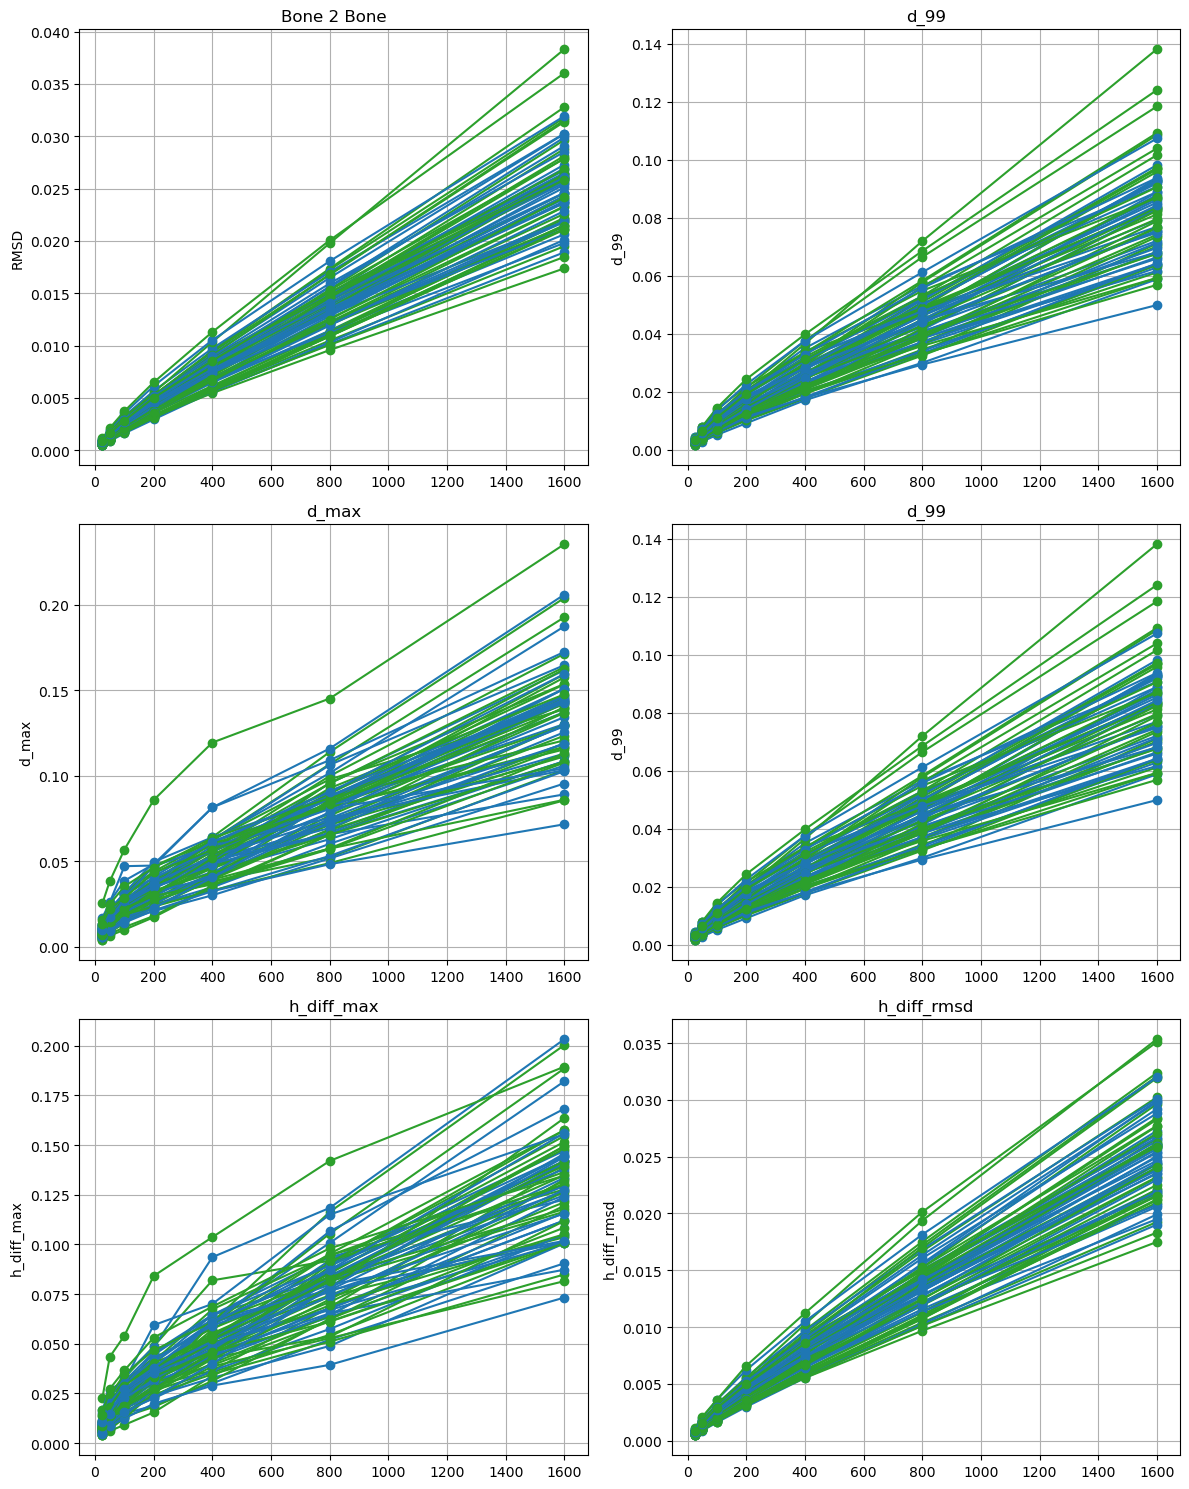

In [70]:
import matplotlib.pyplot as plt

bones = ['tpm', 'mc1']
subs_sides = df['sub'].unique()
x = df['n_iter'].unique()

# plot
fig, ax = plt.subplots(3, 2, figsize=(12, 15))
ax = ax.flatten()

c_map = {
    'tpm': 'tab:blue',
    'mc1': 'tab:green'
}

for sub in subs_sides:
    #sub_df = df[(df['sub'] == sub) & (df['bone']==bone)]
    for bone in bones:
        sub_df = df[(df['sub'] == sub) & (df['bone']==bone)]
        c = c_map[bone]
    #x = sub_df['cells_field'][::-1]

        ax[0].plot(x, sub_df['rmsd'], marker='o', c=c)
        ax[0].set_title('Bone 2 Bone')
        ax[0].set_ylabel('RMSD')

        ax[1].plot(x, sub_df['d_99'], marker='o', c=c)
        ax[1].set_title('d_99')
        ax[1].set_ylabel('d_99')

        ax[2].plot(x, sub_df['d_max'], marker='o', c=c)
        ax[2].set_title('d_max')
        ax[2].set_ylabel('d_max')

        ax[5].plot(x, sub_df['h_diff_rmsd'], marker='o', c=c)
        ax[5].set_title('h_diff_rmsd')
        ax[5].set_ylabel('h_diff_rmsd')

        ax[4].plot(x, sub_df['h_diff_max'], marker='o', c=c)
        ax[4].set_title('h_diff_max')
        ax[4].set_ylabel('h_diff_max')

        # ratio of height after to height before - shows what proportion of cartialge height is lost
        ax[3].plot(x, sub_df['d_99'], marker='o', c=c)
        ax[3].set_title('d_99')
        ax[3].set_ylabel('d_99')

        
#LOOK AT H_DIFF RATIO

for ax_i in ax:
    ax_i.grid()  

plt.tight_layout()

In [66]:
df[(df['n_iter']==100) & (df['h_diff_max']>0.05)]

,sub,bone,n_iter,rmsd,h_before_rmsd,h_after_rmsd,h_diff_rmsd,h_ratio_rmsd,d_mean,d_median,...,h_ratio_std,h_ratio_max,h_ratio_99,h_ratio_95,before_points,before_cells,before_A,after_points,after_cells,after_A
373,14613R,mc1,100,0.003729,0.406291,0.405163,0.003604,0.003604,0.002172,0.001252,...,0.012578,0.177904,0.057818,0.023559,5447,10563,155.47618,5447,10563,155.164885


In [69]:
df[(df['n_iter']==100) & (df['d_max']>0.05)]

,sub,bone,n_iter,rmsd,h_before_rmsd,h_after_rmsd,h_diff_rmsd,h_ratio_rmsd,d_mean,d_median,...,h_ratio_std,h_ratio_max,h_ratio_99,h_ratio_95,before_points,before_cells,before_A,after_points,after_cells,after_A
373,14613R,mc1,100,0.003729,0.406291,0.405163,0.003604,0.003604,0.002172,0.001252,...,0.012578,0.177904,0.057818,0.023559,5447,10563,155.47618,5447,10563,155.164885


# Same again except measure change after remeshing

In [72]:
n_samples = 20000
iters = [25, 50, 100, 200, 400, 800, 1600]

remesh_data = []
for sub in tqdm(subs_ok):
    subject, sideL = sub[:-1], sub[-1]
    for bone, ar_bone in [['tpm', 'mc1'], ['mc1', 'tpm']]:   


        output_dir = output_root / f"{subject}{sideL}/{bone}-{ar_bone}"
        output_path = output_dir / '2Dmesh'
        compute_quality = False

        bone_mesh = pv.read(output_path / f'bone_remesh{mesh_id}.obj')
        ar_path = output_dir.parent / f"{ar_bone}-{bone}/2Dmesh/bone_remesh{mesh_id}.obj"
        arbone_mesh = pv.read(ar_path)

        # compute min df
        stl_path = get_subject_stl_path(subject, sideL)
        max_gap_cartilage = 2
        poses = ['adduction','abduction','flexion','extension','pinch','grasp','jar','neutral']
        min_df = get_min_df_fast(stl_path, bone, ar_bone, bone_mesh, arbone_mesh, poses, max_gap_cartilage)





        # main
        ################# MESH STUFF #################
        bone_mesh['Normals'] = bone_mesh.compute_normals(point_normals=True, cell_normals=False)['Normals']
        bone_mesh['bone_id'] = np.arange(bone_mesh.n_points)
        bone_mesh['bone_cell_id'] = np.arange(bone_mesh.n_cells)
        ################# MESH STUFF #################


        ################# COMPUTE TAPER REGION #################
        # extract mesh of cartilage points on bone mesh (makes gdist computation faster) - (bone-cartilage interface mesh)
        inter_mesh = bone_mesh.extract_points(min_df['bone_id'], adjacent_cells=False).extract_surface(algorithm=None)
        inter_mesh['inter_cell_ids'] = np.arange(inter_mesh.n_cells)
        # remove any missing points due to extract geometry (so remove any points not part of a complete triangle)
        missing_mask = ~np.isin(min_df['bone_id'], inter_mesh['bone_id'])
        min_df.drop(min_df['bone_id'][missing_mask].index.values, inplace=True)

        # useful values from min_df (min_df does not change after this point - final change was at min_df.drop(missing))
        midpoint_dist = min_df['dist'] / 2 # distance of midpoint between two bones for each pair of closest points
        midpoints = np.array(min_df['midpoint'].tolist()) # midpoint coordinates
        #ar_points = np.array(min_df['ar_point'].tolist()) # closest points on ar bone to each bone point


        # get boundary of cartilage on inter mesh
        inter_boundary = get_boundary(inter_mesh)
        boundary_mask_inter = np.isin(inter_mesh['bone_id'], inter_boundary['bone_id']) 
        boundary_ids = np.arange(inter_mesh.n_points)[boundary_mask_inter] # on inter_mesh

        # minimum geo dist of every node from closest source_idx
        geo_dists = gdist.compute_gdist(
            inter_mesh.points.astype(np.float64),
            inter_mesh.faces.reshape(-1, 4)[:, 1:].astype(np.int32),
            source_indices=boundary_ids.astype(np.int32), 
        ) 

        # get mask of nodes within taper width and below taper function
        #taper_heights = taper_f(geo_dists, taper_width, max_height, p=p_h)
        #taper_mask = (taper_heights <= min_df['dist'] / 2) & (geo_dists<=taper_width)
        taper_mask = geo_dists<=taper_width




        # get taper points mesh (makes computation much faster) - mesh of only taper region
        taper_mask_inter = np.isin(inter_mesh['bone_id'], min_df['bone_id'][taper_mask])
        taper_mesh = inter_mesh.extract_points(taper_mask_inter, adjacent_cells=False).extract_surface(algorithm=None)
            # assign non-taper cells that lie on "pinched" islands to taper region
        not_taper_mesh = inter_mesh.extract_cells(taper_mesh['inter_cell_ids'], invert=True).extract_surface(algorithm=None)
        edge_map, adjacency = get_triangle_adjacency(not_taper_mesh)
        start_face = not_taper_mesh.find_closest_cell(np.mean(not_taper_mesh.points, axis=0)) # not best way of doing this!
        inner_cells = flood_fill_cells(not_taper_mesh, start_face, get_boundary(not_taper_mesh).lines.reshape(-1, 3)[:, 1:], adjacency)
            # final taper mesh #
        taper_mesh = inter_mesh.extract_cells(not_taper_mesh['inter_cell_ids'][inner_cells], invert=True).extract_surface(algorithm=None)
            # remove any missing points from taper_mask after extracting geometry and islands - not ideal but quicker than using inter mesh
        taper_mask = np.isin(min_df['bone_id'], taper_mesh['bone_id'])
        #taper_geo_dists = geo_dists[taper_mask]

        # geo_dist between all points within max_distance
        geo_dists_matrix = gdist.local_gdist_matrix(
            taper_mesh.points.astype(np.float64),
            taper_mesh.faces.reshape(-1, 4)[:, 1:].astype(np.int32),
            max_distance=taper_width+1e-3
        ) 

        # get taper mesh boundaries
        taper_boundary = get_boundary(taper_mesh)
        boundary_outer_mask_tb = np.isin(taper_boundary['bone_id'], inter_boundary['bone_id']) # on taper_boundary

        # get taper boundary innner and outer nodes on taper mesh
        taper_outer_mask = np.isin(taper_mesh['bone_id'], taper_boundary['bone_id'][boundary_outer_mask_tb]) # on taper_mesh
        taper_inner_mask = np.isin(taper_mesh['bone_id'], taper_boundary['bone_id'][~boundary_outer_mask_tb]) # on taper_mesh
        taper_outer_ids = np.arange(taper_mesh.n_points)[taper_outer_mask] # on taper_mesh
        taper_inner_ids = np.arange(taper_mesh.n_points)[taper_inner_mask] # on taper_mesh

        # ids and distances of boundary nodes that are closest to each taper node
        _, near_taper_outer_D = get_nearest_boundary(taper_outer_ids, geo_dists_matrix) # ids on taper_mesh
        near_taper_inner_ids, near_taper_inner_D = get_nearest_boundary(taper_inner_ids, geo_dists_matrix) # ids on taper_mesh
        # Distance fraction of each taper_mesh point from closest outer_node to closest_inner node
        taper_Df = (near_taper_outer_D) / (near_taper_outer_D + near_taper_inner_D)

        # get nearest inner node midpoint heights
        taper_inner_mask_c = np.isin(min_df['bone_id'], taper_mesh['bone_id'][taper_inner_ids]) # on c_mesh
        inner_node_midpoint_heights = midpoint_dist.values[taper_inner_mask_c]
        near_inner_node_midpoint_heights = inner_node_midpoint_heights[np.searchsorted(taper_inner_ids, near_taper_inner_ids)]

        # set taper node heights
        taper_heights = taper_f(taper_Df, 1, near_inner_node_midpoint_heights, p=p_h) # non-linear

        # set vector directions
        midpoint_vecs = midpoints - bone_mesh.points[min_df['bone_id']] # vector from bone point to midpoint
        taper_vecs_mid = midpoint_vecs[taper_mask] # midpoint_vecs
        taper_vecs_norm = bone_mesh['Normals'][min_df['bone_id']][taper_mask] # normal vecs
        vec_dirs = taper_f(taper_Df, 1, 1, p=p_v)
        taper_vecs = interp_vecs(taper_vecs_norm, taper_vecs_mid, vec_dirs)

        # get taper coords
        taper_points = bone_mesh.points[min_df['bone_id']][taper_mask]
        taper_points = taper_points + taper_heights.reshape(-1, 1)*taper_vecs

        # get taper points
        points_tapered = midpoints.copy()
        points_tapered[taper_mask] = taper_points

        #closest_points, distances, cell_ids = get_trimesh(bone_mesh).nearest.on_surface(points_tapered)
        ################# COMPUTE TAPER REGION #################

        ################# MESH TAPER REGION #################
        # map faces from bone mesh to extruded taper region points
        # mesh curves down in taper region and delaunay doesn't like that
        tapered_mesh = pv.PolyData(taper_points, taper_mesh.faces)
        ################# MESH TAPER REGION #################




        ################# MESH INNER REGION #################
        tapered_edge = get_boundary(tapered_mesh)

        inner_edge = tapered_edge.extract_points(~boundary_outer_mask_tb).extract_surface(algorithm=None)
        #inner_points = pv.PolyData(midpoints[~taper_mask])
        inner_mesh = pv.PolyData(np.vstack( (inner_edge.points, midpoints[~taper_mask]) ), lines=inner_edge.lines)

        # alpha for coarse meshes wants to be slightly lower and vice versa - I think
        inner_mesh = inner_mesh.delaunay_2d(edge_source=inner_edge, alpha=0.9).triangulate()
        inner_mesh = inner_mesh.fill_holes(inner_mesh.area/20)
        #inner_mesh.lines = inner_edge.lines # reset edge lines to remove delaunay leftover lines
        inner_mesh.lines = np.empty(0, dtype='int64') # remove all lines for now cos they show up in mesh.faces

        # remove cells that lie outside of the inner region boundary
        edge_map, adjacency = get_triangle_adjacency(inner_mesh)
        #start_face = inner_mesh.find_closest_cell(np.mean(inner_mesh.points, axis=0))
        start_face = inner_mesh.find_closest_cell(inner_mesh.center) # new 28/03/26
        inner_cells = flood_fill_cells(inner_mesh, start_face, inner_edge.lines.reshape(-1, 3)[:, 1:], adjacency)
        inner_mesh_clean = pv.PolyData(inner_mesh.points, inner_mesh.faces.reshape(-1, 4)[inner_cells])
        # should maybe be calling remove unused points here, lines bring their own points that are left behind?
        ################# MESH INNER REGION #################




        ################# COMBINE INNER MESH AND TAPER MESH #################
        #edge_check1 = np.isin(inner_edge.points, tapered_mesh.points).all()
        edge_check1 = identical_points_count(inner_edge.points, tapered_mesh.points) == inner_edge.n_points #*** new
        #edge_check2 = np.isin(inner_edge.points, inner_mesh_clean.points).all()
        edge_check2 = identical_points_count(inner_edge.points, inner_mesh_clean.points) == inner_edge.n_points #*** new

        inner_mesh_clean['inner_cells'] = np.full(inner_mesh_clean.n_cells, 1)
        tapered_mesh['inner_cells'] = np.full(tapered_mesh.n_cells, 0)
        mesh = inner_mesh_clean + tapered_mesh # full cartilage cap mesh
            # check if there are any holes at boundary between inner mesh and tapered mesh and try to fill them
        if get_boundary(mesh).connectivity()['RegionId'].any():
            mesh = fill_holes_pmf(mesh, nbe=20)
            mesh['inner_cells'] = np.ones(mesh.n_cells, dtype=int)
            mesh['inner_cells'][find_corresponding_cells(mesh, tapered_mesh, raise_error=True)] = 0
        else:
            if not mesh.n_points == midpoints.shape[0]: # had to move to else cos pymeshfix messes with stuff sometimes
                raise AssertionError('Not all midpoints in mesh (& no dupes)')

        if not edge_check1:
            raise AssertionError('Not all boundary points in tapered mesh')
        if not edge_check2:
            raise AssertionError('Not all boundary points in inner mesh')

        # check for flat faces
        #closest_points, implicit_distances, cell_ids = get_trimesh(bone_mesh).nearest.on_surface(mesh.points)
        _, ps = bone_mesh.find_closest_cell(mesh.points, return_closest_point=True)
        implicit_distances = np.linalg.norm(mesh.points - ps, axis=1) #*** changed from line above

        mesh_faces = mesh.faces.reshape(-1, 4)[:, 1:]
        flat_face_mask = (implicit_distances[mesh_faces] <= 1e-12).all(axis=1) #*** changed from ==0 to <=1e-12
        #flat_face_ids = np.where(flat_face_mask)[0]

        # remove flat faces and leftover points - occur when all 3 vertices lie on the boundary
        mesh_clean = pv.PolyData(mesh.points, mesh.faces.reshape(-1, 4)[~flat_face_mask]).compute_normals(auto_orient_normals=True)
        mesh_clean.remove_unused_points(inplace=True)
        mesh_clean['mesh_clean_id'] = np.arange(mesh_clean.n_points)
        # get array of inner points/cells on mesh_clean 
        mesh_clean['inner_cells'] = mesh['inner_cells'][find_corresponding_cells(mesh, mesh_clean)]
        mesh_clean['inner_points'] = np.full(mesh_clean.n_points, 1)
        mesh_clean['inner_points'][np.unique(mesh_clean.faces.reshape(-1, 4)[:, 1:][np.where(mesh_clean['inner_cells']==0)[0]])] = 0
        #mesh_clean['inner_points'] = np.zeros(mesh_clean.n_points, dtype=int)
        #for p in inner_mesh_clean.points:
        #    mesh_clean['inner_points'][mesh_clean.find_closest_point(p)] = 1

        # get edge points on mesh and bone_mesh
        mesh_clean_edge = get_boundary(mesh_clean)
        mesh_clean_edge_mask = np.isin(mesh_clean['mesh_clean_id'], mesh_clean_edge['mesh_clean_id']) # on mesh_clean
        mesh_edge_ids = mesh_clean['mesh_clean_id'][mesh_clean_edge_mask] # on mesh_clean
        mesh_edge_points = mesh_clean.points[mesh_clean_edge_mask] # on mesh_clean

        #print('Checking mesh boundary has not changed')
        #bone_mesh_edge_ids = check_points_still_there(bone_mesh, mesh_edge_points)
        _, bone_mesh_edge_ids, _ = identical_points_count(bone_mesh.points, mesh_edge_points, return_indices=True) #*** new
        bone_mesh_edge_ids = np.sort(bone_mesh_edge_ids)
        if len(bone_mesh_edge_ids) != len(mesh_edge_points):
            raise AssertionError("Mesh boundary has changed")


        if (mesh.n_cells - mesh_clean.n_cells) != flat_face_mask.sum():
            raise AssertionError("Not all flat faces removed")
        ################# COMBINE INNER MESH AND TAPER MESH #################
        #print('Created cartilage cap')




        for n_iter in iters:
            #print('Smoothing cartilage cap')
            ################# SMOOTH CARTILAGE MESH CAP #################
            cartilage_cap = mesh_clean.smooth(
            n_iter=n_iter,
            feature_angle=180, # prevent anything from being feature cos I don't understant feature_smoothing arg...
            boundary_smoothing = False, # keeps boundary fixed-ish
            feature_smoothing = False # prevents feature edges from being identified - so they get smoothed?... (idk stupid)
            )
            cartilage_cap_edge = get_boundary(cartilage_cap)

            if cartilage_cap_edge.n_points != mesh_clean_edge.n_points:
                raise AssertionError(f'{cartilage_cap_edge.n_points - mesh_clean_edge.n_points} Boundary points lost during smoothing')
            #_ = check_points_still_there(mesh_clean_edge, cartilage_cap_edge.points)

            # put edge points back so they are numerically identical
            cartilage_cap.points[mesh_edge_ids] = bone_mesh.points[bone_mesh_edge_ids]





            ################# REMESH CARTILAGE #################
            # remesh cartilage with CGAL fixed boundary - check boundary hasn't moved (and put points back anyway)
            # this is the final step in creating the cartilage cap mesh (just need to attach to bone after this - trivial)

            print('Writing mesh to remeshing input directory')
            cartilage_cap.save(cgal_input_path)

            print('Remeshing cartilage cap')

            cgal_path = cgal_input_path.parent.parent.parent
            cgal_output_path = cgal_path / 'outputs/fb_output' / cgal_input_path.name
            args = [
                str(cgal_path / "bin/fixed_boundary"),
                str(cgal_input_path),  # path to input mesh
                str(cgal_output_path), # path to output mesh
                str(edge_length), # target edge length
                str(n_iters), # number of CGAL isotropic remeshing iterations
                ]

            result = subprocess.run(args, text=True)
            result.check_returncode()  # raise after printing




            # load remeshed cartilage cap
            cartilage_remesh = pv.read(cgal_output_path)
            cartilage_remesh['remesh_ids'] = np.arange(cartilage_remesh.n_points)

            # check boudnary hasn't moved
            #print('Checking mesh boundary has not changed')
            cartilage_remesh_edge = get_boundary(cartilage_remesh)
            if cartilage_remesh_edge.n_points != cartilage_cap_edge.n_points:
                raise ValueError(f'{cartilage_remesh_edge.n_points - cartilage_cap_edge.n_points} Boundary points lost in remeshing')
            
            #cartilage_cap_edge_ids = check_points_still_there(cartilage_cap_edge, cartilage_remesh_edge.points)
            remesh_edge_dists = cdist(cartilage_cap_edge.points, cartilage_remesh_edge.points) #*** new
            cartilage_cap_edge_ids = np.argmin(remesh_edge_dists, axis=0)
            closest_dists = np.min(remesh_edge_dists, axis=0)
            if (closest_dists > 1e-5).any():
                raise AssertionError(f"Cartilage boundary points moved during remeshing: {max(closest_dists):.5f} mm")

            # put edge points back so they are numerically identical
            cartilage_remesh.points[cartilage_remesh_edge['remesh_ids']] = cartilage_cap_edge.points[cartilage_cap_edge_ids]

            # measure cartilage height and store in mesh
            cartilage_remesh_height = cartilage_remesh.compute_implicit_distance(bone_mesh)['implicit_distance']
            if (cartilage_remesh_height < 0).any():
                break # moves on to next bone - doesn't try anymore smoothing iters
                #raise AssertionError('Not all cartilage points above bone surface') # detect interference

            # add cartilge taper/inner region array
            cartilage_remesh['inner_cells'] = cartilage_cap['inner_cells'][cartilage_cap.find_closest_cell(cartilage_remesh.cell_centers().points)]
            cartilage_remesh['inner_points'] = np.full(cartilage_remesh.n_points, -1)
            cartilage_remesh['inner_points'][np.unique(cartilage_remesh.faces.reshape(-1, 4)[:, 1:][np.where(cartilage_remesh['inner_cells']==1)[0]])] = 1
            cartilage_remesh['inner_points'][np.unique(cartilage_remesh.faces.reshape(-1, 4)[:, 1:][np.where(cartilage_remesh['inner_cells']==0)[0]])] = 0






            # distance of inner points from mesh
            inner_remesh = cartilage_remesh.extract_points(cartilage_remesh['inner_points'].astype(bool), adjacent_cells=False).extract_surface(algorithm=None)
            inner_clean = mesh_clean.extract_points(mesh_clean['inner_points'].astype(bool), adjacent_cells=False).extract_surface(algorithm=None)

            d_ab = compute_dists(sample_surface(inner_remesh, n_samples), mesh_clean)
            d_ba = compute_dists(sample_surface(inner_clean, n_samples), cartilage_remesh)
            d = np.hstack((d_ab, d_ba))

            clean_sample = sample_surface(inner_clean, n_samples)
            _, remesh_sample = inner_remesh.find_closest_cell(clean_sample, return_closest_point=True)
            
            h_before = compute_dists(clean_sample, bone_mesh) # before 2 bone
            h_after = compute_dists(remesh_sample, bone_mesh) # after 2 bone
            h_diff = h_before - h_after
            h_ratio = h_diff / h_before

            mets = {
                'sub': sub,
                'bone': bone,
                'n_iter': n_iter,
                'rmsd': compute_rmsd(d),
                'h_before_rmsd': compute_rmsd(h_before),
                'h_after_rmsd': compute_rmsd(h_after),
                'h_diff_rmsd': compute_rmsd(h_diff),
                'h_ratio_rmsd': compute_rmsd(h_diff)
            }
            # distance
            mets = compute_d_metrics(d, mets, 'd_')
            mets = compute_d_metrics(h_before, mets, 'h_before_')
            mets = compute_d_metrics(h_after, mets, 'h_after_')
            mets = compute_d_metrics(h_diff, mets, 'h_diff_')
            mets = compute_d_metrics(h_ratio, mets, 'h_ratio_')  
            # surface
            mets = compute_mesh_metrics(inner_clean, mets, vol=False, edge_length=False, label='before_')
            mets = compute_mesh_metrics(inner_remesh, mets, vol=False, edge_length=False, label='after_')

            remesh_data.append(mets)
pd.DataFrame(remesh_data).to_csv('taperRemeshMetrics-redo.csv', index=False)

  0%|          | 0/36 [00:00<?, ?it/s]

Writing mesh to remeshing input directory
Remeshing cartilage cap
Remeshing complete.
Writing mesh to remeshing input directory
Remeshing cartilage cap
Remeshing complete.
Writing mesh to remeshing input directory
Remeshing cartilage cap
Remeshing complete.
Writing mesh to remeshing input directory
Remeshing cartilage cap
Remeshing complete.
Writing mesh to remeshing input directory
Remeshing cartilage cap
Remeshing complete.
Writing mesh to remeshing input directory
Remeshing cartilage cap
Remeshing complete.
Writing mesh to remeshing input directory
Remeshing cartilage cap
Remeshing complete.
Writing mesh to remeshing input directory
Remeshing cartilage cap
Remeshing complete.
Writing mesh to remeshing input directory
Remeshing cartilage cap
Remeshing complete.
Writing mesh to remeshing input directory
Remeshing cartilage cap
Remeshing complete.
Writing mesh to remeshing input directory
Remeshing cartilage cap
Remeshing complete.
Writing mesh to remeshing input directory
Remeshing ca

  3%|▎         | 1/36 [00:17<10:01, 17.19s/it]

Writing mesh to remeshing input directory
Remeshing cartilage cap
Remeshing complete.
Writing mesh to remeshing input directory
Remeshing cartilage cap
Remeshing complete.
Writing mesh to remeshing input directory
Remeshing cartilage cap
Remeshing complete.
Writing mesh to remeshing input directory
Remeshing cartilage cap
Remeshing complete.
Writing mesh to remeshing input directory
Remeshing cartilage cap
Remeshing complete.
Writing mesh to remeshing input directory
Remeshing cartilage cap
Remeshing complete.
Writing mesh to remeshing input directory
Remeshing cartilage cap
Remeshing complete.
Writing mesh to remeshing input directory
Remeshing cartilage cap
Remeshing complete.
Writing mesh to remeshing input directory
Remeshing cartilage cap
Remeshing complete.
Writing mesh to remeshing input directory
Remeshing cartilage cap
Remeshing complete.
Writing mesh to remeshing input directory
Remeshing cartilage cap
Remeshing complete.
Writing mesh to remeshing input directory
Remeshing ca

  6%|▌         | 2/36 [00:32<09:13, 16.27s/it]

...

 94%|█████████▍| 34/36 [10:42<00:41, 20.75s/it]

Writing mesh to remeshing input directory
Remeshing cartilage cap
Remeshing complete.
Writing mesh to remeshing input directory
Remeshing cartilage cap
Remeshing complete.
Writing mesh to remeshing input directory
Remeshing cartilage cap
Remeshing complete.
Writing mesh to remeshing input directory
Remeshing cartilage cap
Remeshing complete.
Writing mesh to remeshing input directory
Remeshing cartilage cap
Remeshing complete.
Writing mesh to remeshing input directory
Remeshing cartilage cap
Remeshing complete.
Writing mesh to remeshing input directory
Remeshing cartilage cap
Remeshing complete.
Writing mesh to remeshing input directory
Remeshing cartilage cap
Remeshing complete.
Writing mesh to remeshing input directory
Remeshing cartilage cap
Remeshing complete.
Writing mesh to remeshing input directory
Remeshing cartilage cap
Remeshing complete.
Writing mesh to remeshing input directory
Remeshing cartilage cap
Remeshing complete.
Writing mesh to remeshing input directory
Remeshing ca

 97%|█████████▋| 35/36 [10:59<00:19, 19.67s/it]

Writing mesh to remeshing input directory
Remeshing cartilage cap
Remeshing complete.
Writing mesh to remeshing input directory
Remeshing cartilage cap
Remeshing complete.
Writing mesh to remeshing input directory
Remeshing cartilage cap
Remeshing complete.
Writing mesh to remeshing input directory
Remeshing cartilage cap
Remeshing complete.
Writing mesh to remeshing input directory
Remeshing cartilage cap
Remeshing complete.
Writing mesh to remeshing input directory
Remeshing cartilage cap
Remeshing complete.
Writing mesh to remeshing input directory
Remeshing cartilage cap
Remeshing complete.
Writing mesh to remeshing input directory
Remeshing cartilage cap
Remeshing complete.
Writing mesh to remeshing input directory
Remeshing cartilage cap
Remeshing complete.
Writing mesh to remeshing input directory
Remeshing cartilage cap
Remeshing complete.
Writing mesh to remeshing input directory
Remeshing cartilage cap
Remeshing complete.
Writing mesh to remeshing input directory
Remeshing ca

100%|██████████| 36/36 [11:19<00:00, 18.87s/it]


In [73]:
df = pd.read_csv('taperRemeshMetrics-redo.csv')
df

,sub,bone,n_iter,rmsd,h_before_rmsd,h_after_rmsd,h_diff_rmsd,h_ratio_rmsd,d_mean,d_median,...,h_ratio_std,h_ratio_max,h_ratio_99,h_ratio_95,before_points,before_cells,before_A,after_points,after_cells,after_A
0,14818R,tpm,25,0.001204,0.468142,0.467660,0.001298,0.001298,0.000750,0.000472,...,0.002583,0.049783,0.009094,0.004806,2973,5721,76.582988,2881,5539,76.209337
1,14818R,tpm,50,0.001735,0.466317,0.465517,0.001845,0.001845,0.001118,0.000724,...,0.003503,0.048052,0.012797,0.007104,2973,5721,76.582988,2872,5521,76.213096
2,14818R,tpm,100,0.002881,0.467148,0.465697,0.002869,0.002869,0.001901,0.001250,...,0.005227,0.039544,0.018836,0.011380,2973,5721,76.582988,2878,5533,76.345095
3,14818R,tpm,200,0.004771,0.466162,0.463525,0.004816,0.004816,0.003290,0.002292,...,0.008570,0.059936,0.030225,0.019701,2973,5721,76.582988,2869,5516,76.491395
4,14818R,tpm,400,0.008278,0.466927,0.462012,0.008192,0.008192,0.005865,0.004235,...,0.014399,0.080404,0.050594,0.033418,2973,5721,76.582988,2853,5483,76.548315
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
399,15283R,mc1,50,0.001978,0.351039,0.350321,0.001947,0.001947,0.001178,0.000688,...,0.005504,0.069968,0.020991,0.011888,4408,8538,130.185167,4443,8602,130.031720
400,15283R,mc1,100,0.003145,0.349924,0.348615,0.003189,0.003189,0.001943,0.001157,...,0.008862,0.156368,0.032748,0.019186,4408,8538,130.185167,4407,8533,129.967771
401,15283R,mc1,200,0.005159,0.350980,0.348678,0.005239,0.005239,0.003306,0.002008,...,0.014566,0.169739,0.051893,0.032925,4408,8538,130.185167,4396,8508,129.990344
402,15283R,mc1,400,0.008800,0.350956,0.346761,0.008763,0.008763,0.005873,0.003692,...,0.025339,0.243015,0.087214,0.056457,4408,8538,130.185167,4389,8496,130.063166


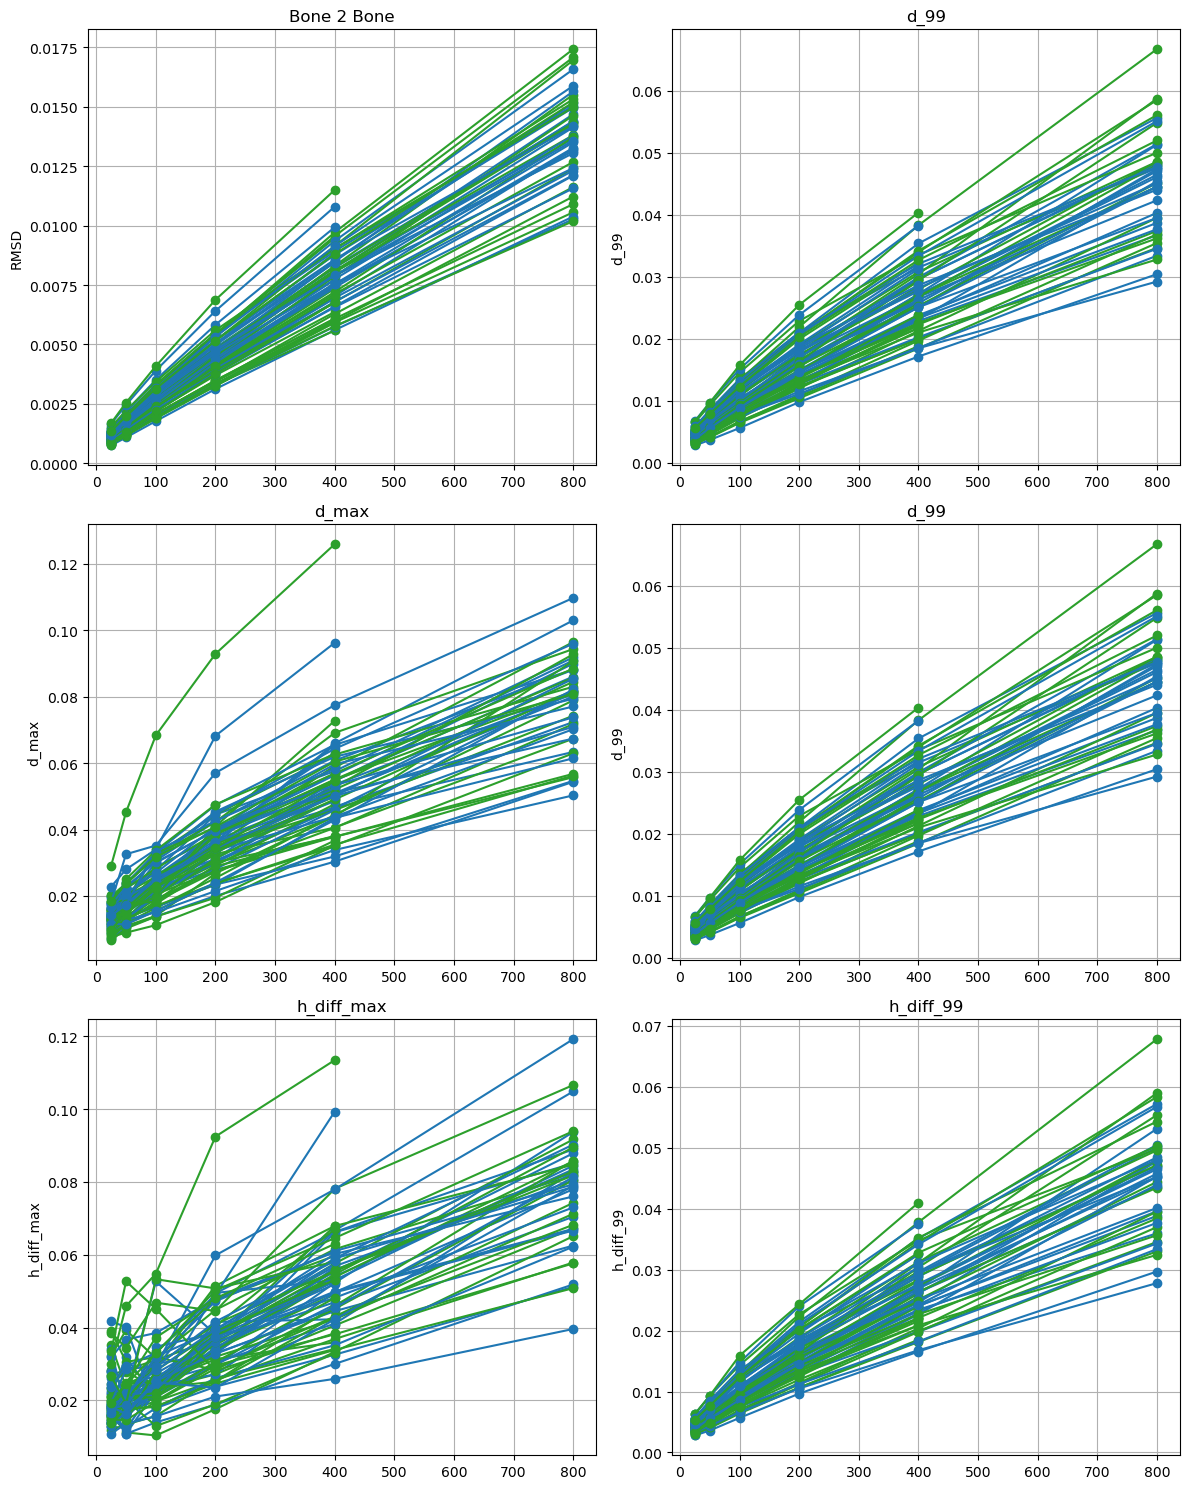

In [78]:
import matplotlib.pyplot as plt

bones = ['tpm', 'mc1']
subs_sides = df['sub'].unique()

# plot
fig, ax = plt.subplots(3, 2, figsize=(12, 15))
ax = ax.flatten()

c_map = {
    'tpm': 'tab:blue',
    'mc1': 'tab:green'
}

for sub in subs_sides:
    #sub_df = df[(df['sub'] == sub) & (df['bone']==bone)]
    for bone in bones:
        sub_df = df[(df['sub'] == sub) & (df['bone']==bone)]
        x = sub_df['n_iter'].unique()
        c = c_map[bone]
    #x = sub_df['cells_field'][::-1]

        ax[0].plot(x, sub_df['rmsd'], marker='o', c=c)
        ax[0].set_title('Bone 2 Bone')
        ax[0].set_ylabel('RMSD')

        ax[1].plot(x, sub_df['d_99'], marker='o', c=c)
        ax[1].set_title('d_99')
        ax[1].set_ylabel('d_99')

        ax[2].plot(x, sub_df['d_max'], marker='o', c=c)
        ax[2].set_title('d_max')
        ax[2].set_ylabel('d_max')

        ax[5].plot(x, sub_df['h_diff_99'], marker='o', c=c)
        ax[5].set_title('h_diff_99')
        ax[5].set_ylabel('h_diff_99')

        ax[4].plot(x, sub_df['h_diff_max'], marker='o', c=c)
        ax[4].set_title('h_diff_max')
        ax[4].set_ylabel('h_diff_max')

        # ratio of height after to height before - shows what proportion of cartialge height is lost
        ax[3].plot(x, sub_df['d_99'], marker='o', c=c)
        ax[3].set_title('d_99')
        ax[3].set_ylabel('d_99')

        
#LOOK AT H_DIFF RATIO

for ax_i in ax:
    ax_i.grid()  

plt.tight_layout()

### These arn't much if at all worse that just smoothing so remesh is fine
 - only show after remesh results in write up
 - use d_max to justify - and remove the bad one